In [1]:
import sys
print(sys.version)

3.9.18 (main, Sep 11 2023, 13:30:38) [MSC v.1916 64 bit (AMD64)]


In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'


import zipfile
import random
import shutil
import numpy as np
from shutil import copyfile

%matplotlib inline
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

import tensorflow as tf
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array

In [2]:
print(tf.__version__)

2.10.0


In [6]:
# Run Script One Time to convert original data image from classification data to binary data [DO NOT RUN MORE THAN ONCE!!]

import shutil
import os

# Define Paths
original_dataset_dir = './dataset' 
base_dir = './dataset_binary' 

#create Binary_directory
def organize_binary_data(source_root, dest_root):
    
    os.makedirs(os.path.join(dest_root, 'fresh'), exist_ok=True)
    os.makedirs(os.path.join(dest_root, 'rotten'), exist_ok=True)
    
    for subfolder in os.listdir(source_root):
        source_path = os.path.join(source_root, subfolder)
        
        if not os.path.isdir(source_path): continue
    
        if 'fresh' in subfolder.lower():
            target_folder = 'fresh'
        elif 'rotten' in subfolder.lower():
            target_folder = 'rotten'
        else:
            continue 
    
        print(f"Processing {subfolder} -> Merging into {target_folder}...")
        
        dest_path = os.path.join(dest_root, target_folder)
        for filename in os.listdir(source_path):
            src_file = os.path.join(source_path, filename)
            dst_file = os.path.join(dest_path, filename)
            if not os.path.exists(dst_file):
                shutil.copy(src_file, dst_file)
    
print("Organizing Training Data...")
organize_binary_data(os.path.join(original_dataset_dir, 'train'), os.path.join(base_dir, 'train'))

print("\nOrganizing Validation Data...")
organize_binary_data(os.path.join(original_dataset_dir, 'val'), os.path.join(base_dir, 'val'))

print ("\nOrganizing Test Data")
organize_binary_data(os.path.join(original_dataset_dir, 'test'), os.path.join(base_dir, 'test'))

print("\nDone! New binary dataset created at './dataset_binary'")

Organizing Training Data...
Processing freshapples -> Merging into fresh...
Processing freshbanana -> Merging into fresh...
Processing freshoranges -> Merging into fresh...
Processing rottenapples -> Merging into rotten...
Processing rottenbanana -> Merging into rotten...
Processing rottenoranges -> Merging into rotten...

Organizing Validation Data...
organizing Test Data
Processing freshapples -> Merging into fresh...
Processing freshbanana -> Merging into fresh...
Processing freshoranges -> Merging into fresh...
Processing rottenapples -> Merging into rotten...
Processing rottenbanana -> Merging into rotten...
Processing rottenoranges -> Merging into rotten...

Done! New binary dataset created at './dataset_binary'


In [3]:
# check existing subfolders under new binary data Folder

import os 

base_dir = './dataset_binary' 

train_dir = os.path.join(base_dir, 'train') 
validation_dir = os.path.join(base_dir, 'val') 
test_dir = os.path.join(base_dir, 'test')

print("Checking Train Directory:", test_dir) 
try: 
    print("Folders found:", os.listdir(test_dir)) 
except FileNotFoundError: 
    print("ERROR: Paths are wrong. Please check where your notebook file is saved relative to the dataset folder.") 

Checking Train Directory: ./dataset_binary\test
Folders found: ['fresh', 'rotten']


In [17]:
# Run Script One Time to split training data into validation data by 80/20 

import os
import random
import shutil
 
train_dir = os.path.join(base_dir, 'train') 
validation_dir = os.path.join(base_dir, 'val') 

split = 0.2
random.seed(21)

for cls in ["fresh" , "rotten" ]:
    train_class_dir = os.path.join(train_dir, cls)
    val_class_dir = os.path.join(validation_dir, cls)

    images = os.listdir(train_class_dir)
    random.shuffle(images)

    split_indx = int(len(images) * split)
    val_images = images[:split_indx]

    for img in val_images:
        src = os.path.join(train_class_dir, img)
        dst = os.path.join(val_class_dir, img)
        shutil.move(src, dst)
        
    print (f"{cls}: moved {len(val_images)} images from {train_class_dir} to {val_class_dir}")

fresh: moved 948 images from ./dataset_binary\train\fresh to ./dataset_binary\val\fresh
rotten: moved 1232 images from ./dataset_binary\train\rotten to ./dataset_binary\val\rotten


In [7]:
# script to count number of existing images under sub-folders

def count_images(path):
    for cls in ['fresh', 'rotten']:
        print(cls, len(os.listdir(os.path.join(path, cls))))

print("Train:")
count_images(train_dir)

print("\nValidation:")
count_images(validation_dir)

print("\nTest:")
count_images(test_dir)

Train:
fresh 3792
rotten 4929

Validation:
fresh 948
rotten 1232

Test:
fresh 1164
rotten 1534


In [9]:
# establish the specifications of data augmentation for both training and validation data.

train_datagen = ImageDataGenerator(
    rescale=1./255,
    width_shift_range=0.2, #0.2, 0.5
    height_shift_range=0.2, #0.2, 0.5
    shear_range=0.2,
    zoom_range=[0.5, 1.0], # 0.2, 0.5, [0.5,1.0]
    rotation_range=90, #20, 40, 60, 90
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='reflect' #nearest, reflect, wrap
)

validation_datagen = ImageDataGenerator(
    rescale=1./255
)

Testing augmentation on: ./dataset_binary\train\fresh\rotated_by_15_Screen Shot 2018-06-08 at 5.00.12 PM.png


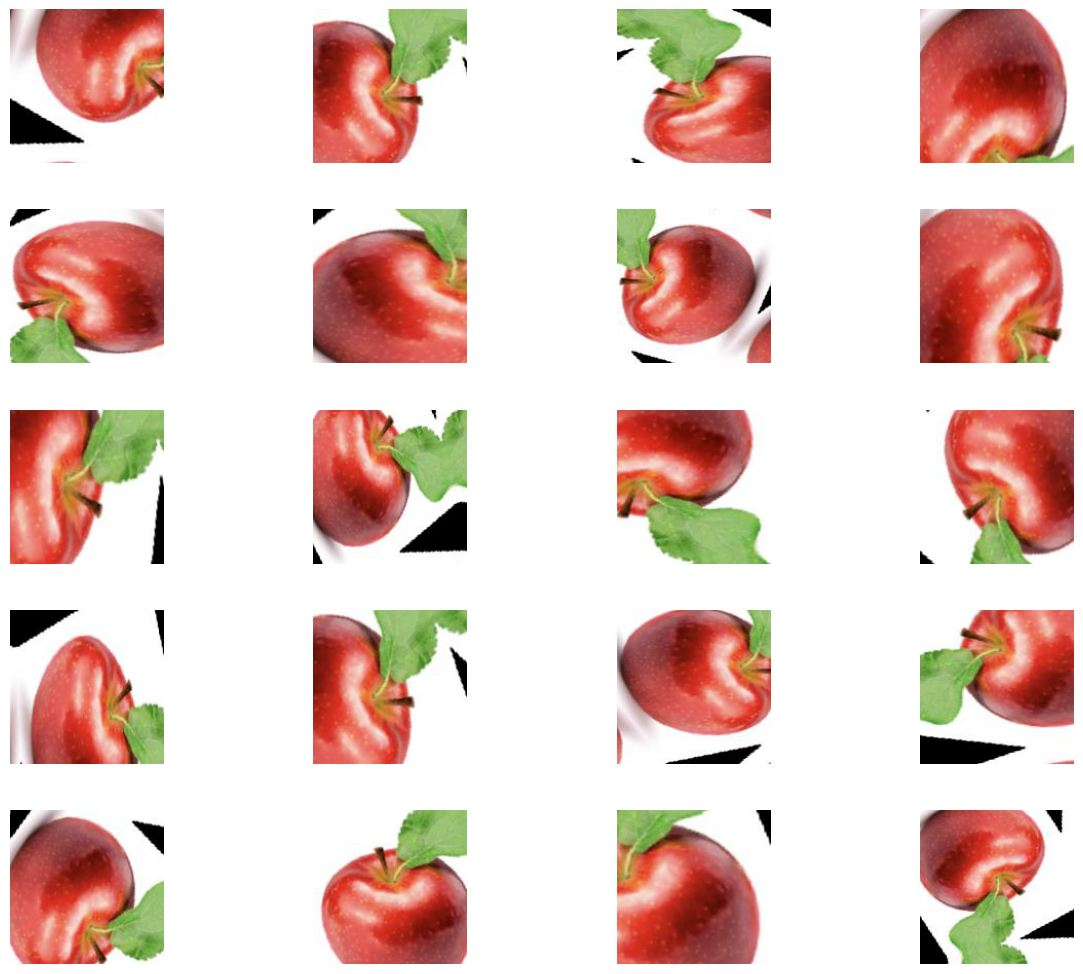

Cleaning up preview files...


In [11]:
# preview image augmentation of a single image to visualize data extension

import matplotlib.pyplot as plt
import os

preview_dir = './preview_aug'
if not os.path.exists(preview_dir):
    os.mkdir(preview_dir)

# Pick a random image from "Fresh" folder to test augmentation
source_folder = os.path.join(train_dir, 'fresh') 
sample_image = os.listdir(source_folder)[3] 
path_aug = os.path.join(source_folder, sample_image)

print(f"Testing augmentation on: {path_aug}")

# Load and Shape the image
img_augmentation = load_img(path_aug, target_size=(150, 150))
x_aug = img_to_array(img_augmentation)
x_aug = x_aug.reshape((1,) + x_aug.shape)

# Generate 20 variations
i = 0
for batch in train_datagen.flow(x_aug, batch_size=1, save_to_dir=preview_dir, save_prefix='fruit', save_format='jpeg'):
    i += 1
    if i >= 20:
        break

# Display augmentation results
preview_img = os.listdir(preview_dir)

plt.figure(figsize=(15, 15))
for n in range(len(preview_img)):
  # Note: Converted the math to int() to avoid errors
  plt.subplot(int(len(preview_img)/4)+1, 4, n+1)
  plt.subplots_adjust(hspace = 0.3)
  
  img_path = os.path.join(preview_dir, preview_img[n])
  plt.imshow(load_img(img_path,
                            color_mode="rgb",
                            target_size=(150, 150),
                            interpolation="nearest"))
  plt.axis('off')
plt.show()


print("Cleaning up preview files...")
for fn in preview_img:
    try:
        os.remove(os.path.join(preview_dir, fn))
    except Exception as e:
        print(f"Could not delete {fn}: {e}")

In [13]:
train_generator = train_datagen.flow_from_directory(train_dir,
                                                    batch_size=32,
                                                    color_mode="rgb",
                                                    # shuffle = False,
                                                    target_size=(150,150), #?
                                                    class_mode='binary',
                                                   )

validation_generator = validation_datagen.flow_from_directory(validation_dir,
                                                              batch_size=32,
                                                              color_mode="rgb",
                                                              shuffle = False,
                                                              target_size=(150,150), #?
                                                              class_mode='binary'
                                                             )

Found 8721 images belonging to 2 classes.
Found 2180 images belonging to 2 classes.


In [35]:
callbacks = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=2,
    restore_best_weights=True,
    verbose=1
)


In [37]:
import tensorflow as tf
from tensorflow.keras.regularizers import l2

# Definition of Sequential CNN
model = tf.keras.models.Sequential([
    # Conv Layer 1:
    tf.keras.layers.Conv2D(
        32, (3,3), 
        activation='relu', 
        input_shape=(150, 150, 3)
    ),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.2), # Randomly turns off neurons to prevent memorization

    # Conv Layer 2
    tf.keras.layers.Conv2D(
        64, (3,3), 
        activation='relu',
    ),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.2),

    # Conv Layer 3
    tf.keras.layers.Conv2D(
        128, (3,3),
        activation='relu',
    ),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.2),

    # Flatten
    tf.keras.layers.Flatten(),
    
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    
    # Output Layer: 1 Neuron (0=Fresh, 1=Rotten)
    tf.keras.layers.Dense(1, activation='sigmoid')
])


# Compile
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_7 (Conv2D)           (None, 148, 148, 32)      896       
                                                                 
 max_pooling2d_7 (MaxPooling  (None, 74, 74, 32)       0         
 2D)                                                             
                                                                 
 dropout_9 (Dropout)         (None, 74, 74, 32)        0         
                                                                 
 conv2d_8 (Conv2D)           (None, 72, 72, 64)        18496     
                                                                 
 max_pooling2d_8 (MaxPooling  (None, 36, 36, 64)       0         
 2D)                                                             
                                                                 
 dropout_10 (Dropout)        (None, 36, 36, 64)       

In [39]:
print(f"Total Training Images: {train_generator.samples}")
print(f"Total Validation Images: {validation_generator.samples}")

Total Training Images: 8721
Total Validation Images: 2180


In [ ]:
print("Starting Baseline Training...")

history_baseline = model.fit(
    train_generator,
    epochs=5,
    validation_data=validation_generator,
    callbacks=[callbacks] 
)

Starting Baseline Training...
Epoch 1/5
273/273 [==============================] - ETA: 0s - loss: 0.4949 - accuracy: 0.7874

<Figure size 640x480 with 0 Axes>

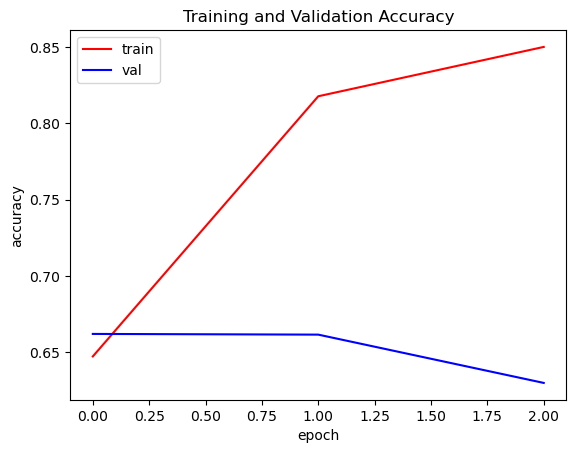

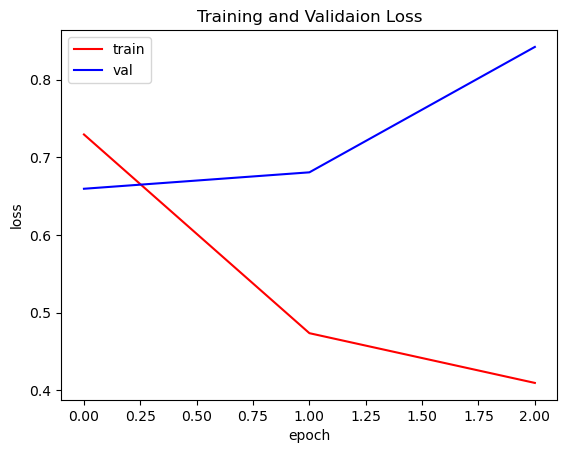

<Figure size 640x480 with 0 Axes>

In [31]:
acc = history_baseline.history['accuracy']
val_acc = history_baseline.history['val_accuracy']
loss = history_baseline.history['loss']
val_loss = history_baseline.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r')
plt.plot(epochs, val_acc, 'b')
plt.title('Training and Validation Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.figure()

plt.plot(epochs, loss, 'r')
plt.plot(epochs, val_loss, 'b')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.title('Training and Validaion Loss')
plt.figure()

In [31]:
# runing tests on previously unseen test data

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(test_dir,
                                                  batch_size=1,
                                                  target_size=(150, 150),
                                                  shuffle=False,
                                                  class_mode='binary' 
                                                 )

filenames = test_generator.filenames
nb_samples = len(filenames)

# Run Evaluation
loss, acc = model.evaluate(test_generator, steps=nb_samples, verbose=1)
print('accuracy test: ', acc)
print('loss test: ', loss)


Found 2698 images belonging to 2 classes.
2698/2698 [==============================] - 89s 33ms/step - loss: 0.3350 - accuracy: 0.8510
accuracy test:  0.8510007262229919
loss test:  0.33500295877456665


In [33]:
print(f"Total test Images: {test_generator.samples}")

Total test Images: 2698


In [35]:
model.save('fresh_rotten_improvedbaseline.h5')

print("Success! Model saved to your folder.")

Success! Model saved to your folder.


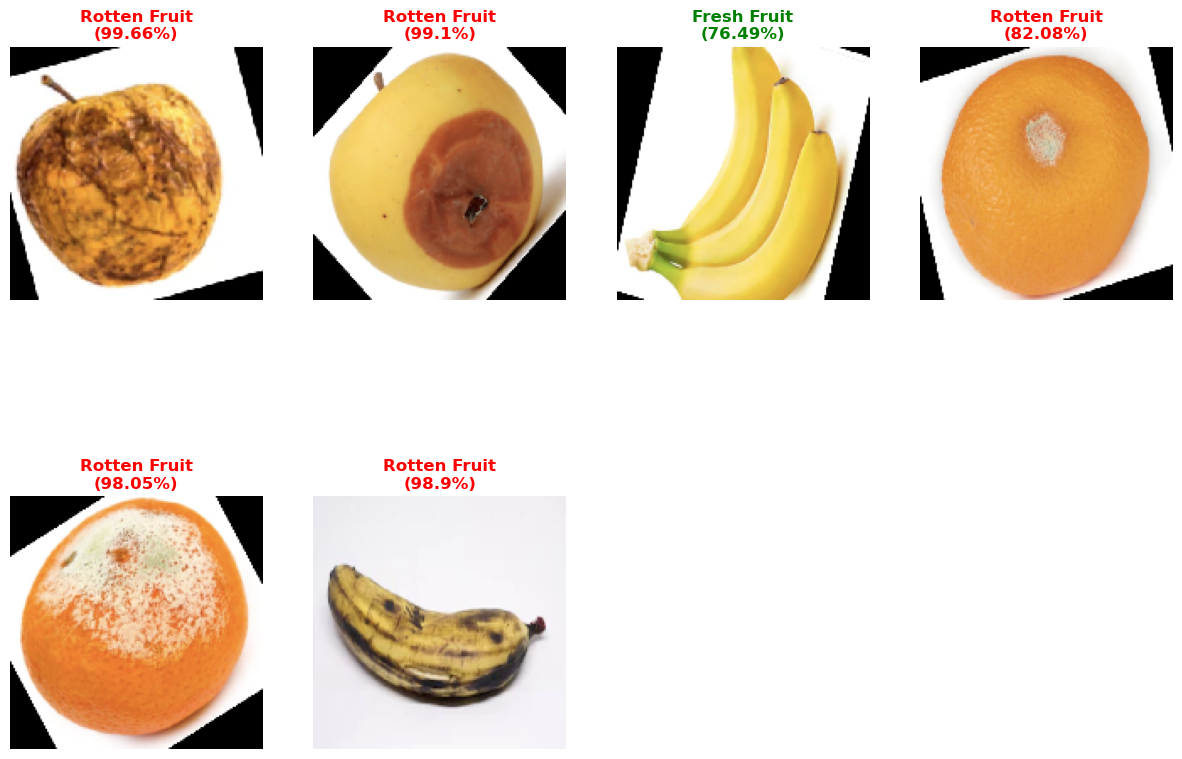

In [47]:
import numpy as np
from tensorflow.keras.preprocessing import image
import random


model_predict = tf.keras.models.load_model('fresh_rotten_improvedbaseline.h5')

all_images = []
for folder in ['fresh', 'rotten']:
    folder_path = os.path.join(validation_dir, folder)
    if os.path.exists(folder_path):
        for img in os.listdir(folder_path):
            all_images.append(os.path.join(folder_path, img))

# Pick 6 random images
file_paths = random.sample(all_images, 6) 

# Lists to store results
image_name = []
image_conf = []
predict_result = []

for path in file_paths:
    # Load image
    img = image.load_img(path, color_mode="rgb", target_size=(150, 150), interpolation="nearest")
    
    # Preprocess (Convert to array, expand dims, normalize)
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = x / 255.0

    # Predict
    classes = model_predict.predict(x, verbose=0) # verbose=0 hides the progress bar
    
    is_rotten = classes[0][0] > 0.5
    
    image_name.append(path)
    
    if not is_rotten:
        # It is Fresh
        image_conf.append(1.0 - classes[0][0])
        predict_result.append('Fresh Fruit')
    else:
        # It is Rotten
        image_conf.append(classes[0][0])
        predict_result.append('Rotten Fruit')


plt.figure(figsize=(15, 10))
num_images = len(image_name)

for n in range(num_images):
    
    rows = int(num_images / 4) + 1
    plt.subplot(rows, 4, n + 1)
    plt.subplots_adjust(hspace=0.4)
    
    # Load and show image
    img_to_show = image.load_img(image_name[n], color_mode="rgb", target_size=(150, 150))
    plt.imshow(img_to_show)
    
    # Title with confidence
    confidence_percent = round(float(image_conf[n]) * 100, 2)
    title_text = f"{predict_result[n]}\n({confidence_percent}%)"
    
    if predict_result[n] == 'Fresh Fruit':
        plt.title(title_text, color='green', fontweight='bold')
    else:
        plt.title(title_text, color='red', fontweight='bold')

    plt.axis('off')

plt.show()

In [96]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

demo_folder_path = './dataset_binary/test/demo' 


model = tf.keras.models.load_model('fresh_rotten_baseline.h5')


demo_files = [f for f in os.listdir(demo_folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]


for i, filename in enumerate(demo_files):
    img_path = os.path.join(demo_folder_path, filename)
    
    img = image.load_img(img_path, target_size=(150, 150))
    
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = x / 255.0
    
    prediction = model.predict(x, verbose=0)[0][0]
    
    if prediction > 0.5:
        label = "Rotten"
        conf = prediction
        col = 'red'
    else:
        label = "Fresh"
        conf = 1 - prediction
        col = 'green'
        
    plt.subplot(2, 4, i+1) 
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{label}\n({conf*100:.1f}%)", color=col, fontweight='bold')

plt.tight_layout()
plt.show()

FileNotFoundError: [WinError 3] The system cannot find the path specified: './dataset_binary/test/demo'